In [1]:
"""
FINUFFT
Here I provide a first try at getting FINUFFT to work. The first step is to install finufft on Tycho,
as far as I recall I simply did

pip install finufft
"""

import finufft
import paicos as pa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib widget

# Load a snapshot and select spherical region (?)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot(pa.data_dir, 247)
# center = snap.Cat.Group['GroupPos'][0]
# R200c = snap.Cat.Group['Group_R_Crit200'][0]
# r_max = 1.0 * R200c
# # index = pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0., r_max)

# widths = np.array([2e3, 2e3, 2e3], dtype=float)
# index = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], center, widths, snap.box)
# snap = snap.select(index, parttype=0)



In [2]:
def power_spectrum_1d(kvec, vhat):
    N = kvec.shape[0]
    M = kvec.shape[0]//2 + 1
    powerspectr = np.zeros(M)
    k1d = np.arange(0, M)
    for i in range(M):
        k_tmp = np.sqrt(kvec**2).astype(dtype='int')
        indices = np.argwhere(k_tmp==k1d[i])
        if (indices.size != 0):
            powerspectr[i] = np.sum((vhat[indices]*np.conj(vhat[indices])).real)/(N*N)
    return powerspectr, k1d

In [3]:
def exp_profile(x, x0, sigma):
    r = np.abs(x - x0)
    return np.exp(-r**2/sigma**2)

N = int(2**10)
# xx = 2.0*np.pi*np.random.uniform(size=N)
xx_uniform = 2.0*np.pi*np.linspace(0,1,N)

### non-uniform grid with gaussian sampling
xx = np.random.normal(loc=np.pi, scale=np.pi, size=(N))
xx[xx>2.0*np.pi] = xx[xx>2.0*np.pi]%(2.0*np.pi)
xx[xx<0.0] = 2.0*np.pi-(-xx[xx<0.0]%(2.0*np.pi))

vec1d = exp_profile(xx, np.pi, np.pi/2.) + 0.0j
vec1d_uniform = exp_profile(xx_uniform, np.pi, np.pi/2.) + 0.0j

vec1d0 = exp_profile(xx, np.pi, np.pi/2.) + 0.0j
vec1d_uniform0 = exp_profile(xx_uniform, np.pi, np.pi/2.) + 0.0j

coeff = []
for i in range(1,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    vec1d += vec1d0*( rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx*i + rnd_phase).real + 0.0j \
                + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*xx*i + rnd_phase).real )
    vec1d_uniform += vec1d_uniform0*( rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx_uniform*i + rnd_phase).real + 0.0j \
                        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*xx_uniform*i + rnd_phase).real )
    coeff.append(rnd_amplitude*(1/(1 + (i-4)**2)))

## background profile plus fluctuations

k1d_target = np.fft.fftfreq(N, d=1.0/N)
vhat1d = finufft.nufft1d3(xx, vec1d, k1d_target, eps=1e-12)
vhat1d_numpy = np.fft.fft(vec1d_uniform)

powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, vhat1d_numpy)
powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, vhat1d)

## fluctuations (1.0 + ...)

delta_vhat1d = finufft.nufft1d3(xx, vec1d/vec1d0, k1d_target, eps=1e-12)
delta_vhat1d_numpy = np.fft.fft(vec1d_uniform/vec1d_uniform0)

delta_powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, delta_vhat1d_numpy)
delta_powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, delta_vhat1d)

## fluctuations (0.0 + ...)

ddelta_vhat1d = finufft.nufft1d3(xx, vec1d/vec1d0-1.0, k1d_target, eps=1e-12)
ddelta_vhat1d_numpy = np.fft.fft(vec1d_uniform/vec1d_uniform0-1.0)

ddelta_powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, ddelta_vhat1d_numpy)
ddelta_powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, ddelta_vhat1d)


## interpolated signal

M = int(N)
k1d_target_interp = np.fft.fftfreq(M, d=1.0/M)
# xx = 2.0*np.pi*np.random.uniform(size=N)
xx_uniform_interp = 2.0*np.pi*np.linspace(0,1,M)

idx_sort = np.argsort(xx)
xx_sorted = xx[idx_sort]
vec_sorted = vec1d[idx_sort]
vec0_sorted = vec1d0[idx_sort]

vec1d_interp = np.interp(xx_uniform_interp, xx_sorted, vec_sorted.real, left=None, right=None, period=2.0*np.pi) + 0j
delta_vec1d_interp = np.interp(xx_uniform_interp, xx_sorted, vec_sorted.real/vec0_sorted.real, left=None, right=None, period=2.0*np.pi) + 0j

vhat1d_numpy_interp = np.fft.fft(vec1d_interp)
powerspectr_numpy_interp, k_shell_interp = power_spectrum_1d(k1d_target_interp, vhat1d_numpy_interp)

delta_vhat1d_numpy_interp = np.fft.fft(delta_vec1d_interp)
delta_powerspectr_numpy_interp, k_shell_interp = power_spectrum_1d(k1d_target_interp, delta_vhat1d_numpy_interp)

ddelta_vhat1d_numpy_interp = np.fft.fft(delta_vec1d_interp - 1.0)
ddelta_powerspectr_numpy_interp, k_shell_interp = power_spectrum_1d(k1d_target_interp, ddelta_vhat1d_numpy_interp)


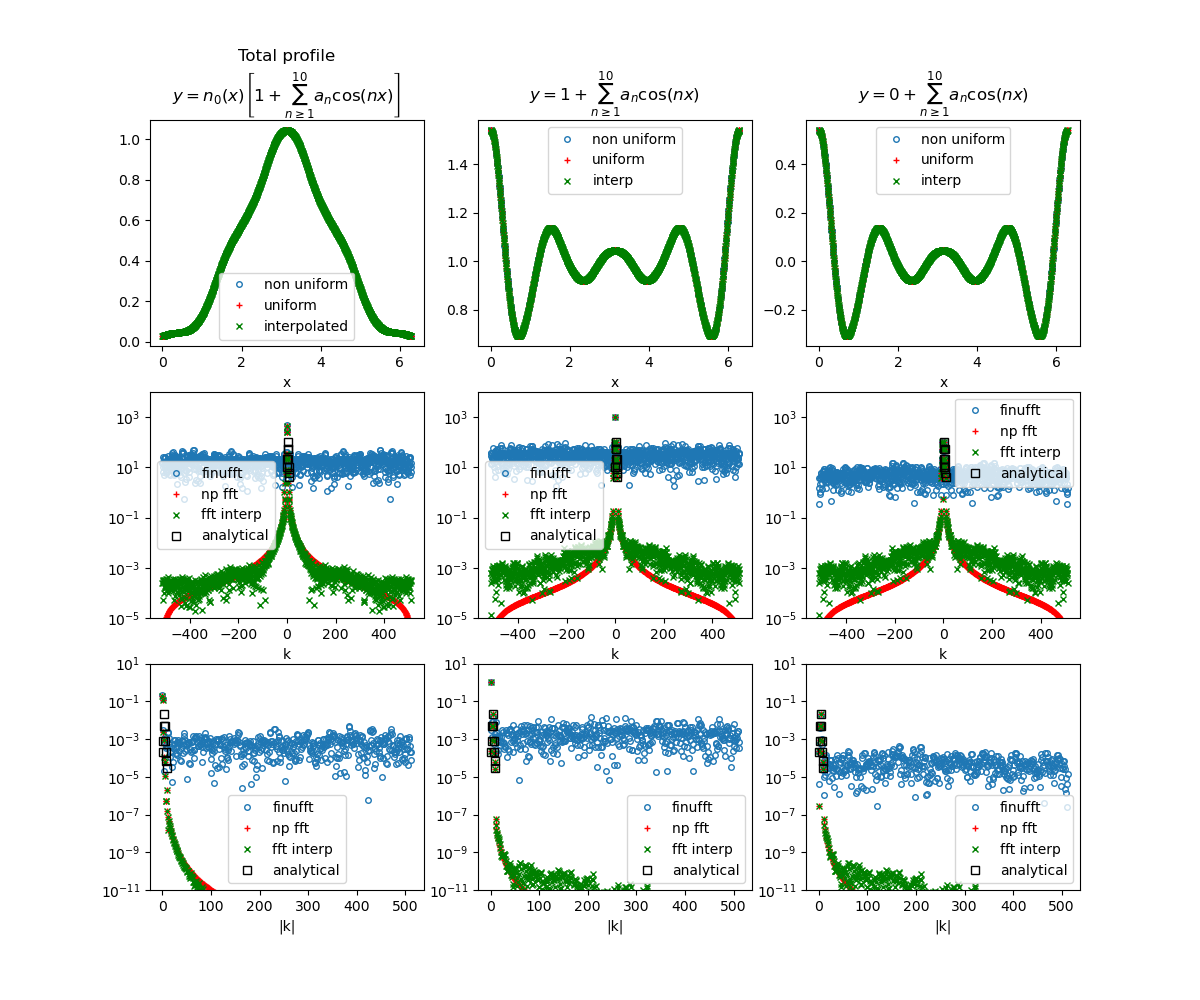

In [4]:
fig, ax = plt.subplots(3,3, figsize=(12,10))

ax[0,0].plot(xx, vec1d.real, ls='', marker='o', markerfacecolor='none', markersize=4, label='non uniform')
ax[0,0].plot(xx_uniform, vec1d_uniform.real, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='uniform')
ax[0,0].plot(xx_uniform_interp, vec1d_interp.real, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='interpolated')
ax[0,0].set_xlabel('x')

ax[1,0].plot(k1d_target, np.abs(vhat1d), ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[1,0].plot(k1d_target, np.abs(vhat1d_numpy), ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np fft')
ax[1,0].plot(k1d_target_interp, np.abs(vhat1d_numpy_interp), ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='fft interp')
ax[1,0].plot(np.arange(1,10), (N)*np.array(coeff), ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[1,0].set_xlabel('k')
ax[1,0].set_yscale('log')

ax[2,0].plot(k_shell, powerspectr_finufft, ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[2,0].plot(k_shell, powerspectr_numpy, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np fft')
ax[2,0].plot(k_shell_interp, powerspectr_numpy_interp, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='fft interp')
ax[2,0].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[2,0].set_xlabel('|k|')
ax[2,0].set_yscale('log')

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()

ax[0,0].set_title('Total profile'+'\n'+r'$y = n_0 (x) \left[ 1 + \sum_{n \geq 1}^{10} a_n \cos (n x) \right]$')

#################################
## middle panel
#################################

ax[0,1].plot(xx, vec1d.real / vec1d0.real, ls='', marker='o', markerfacecolor='none', markersize=4, label='non uniform')
ax[0,1].plot(xx_uniform, vec1d_uniform.real / vec1d_uniform0.real, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='uniform')
ax[0,1].plot(xx_uniform_interp, delta_vec1d_interp.real , ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='interp')
ax[0,1].set_xlabel('x')

ax[1,1].plot(k1d_target, np.abs(delta_vhat1d), ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[1,1].plot(k1d_target, np.abs(delta_vhat1d_numpy), ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np fft')
ax[1,1].plot(k1d_target_interp, np.abs(delta_vhat1d_numpy_interp), ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='fft interp')
ax[1,1].plot(np.arange(1,10), (N)*np.array(coeff), ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[1,1].set_xlabel('k')
ax[1,1].set_yscale('log')

ax[2,1].plot(k_shell, delta_powerspectr_finufft, ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[2,1].plot(k_shell, delta_powerspectr_numpy, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np fft')
ax[2,1].plot(k_shell_interp, delta_powerspectr_numpy_interp, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='fft interp')
ax[2,1].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[2,1].set_xlabel('|k|')
ax[2,1].set_yscale('log')

ax[0,1].legend()
ax[1,1].legend()
ax[2,1].legend()

ax[0,1].set_title(r'$y = 1 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')

#################################
## right panel
#################################

ax[0,2].plot(xx, vec1d.real / vec1d0.real - 1.0, ls='', marker='o', markerfacecolor='none', markersize=4, label='non uniform')
ax[0,2].plot(xx_uniform, vec1d_uniform.real / vec1d_uniform0.real - 1.0, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='uniform')
ax[0,2].plot(xx_uniform_interp, delta_vec1d_interp.real - 1.0, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='interp')
ax[0,2].set_xlabel('x')

ax[1,2].plot(k1d_target, np.abs(ddelta_vhat1d), ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[1,2].plot(k1d_target, np.abs(ddelta_vhat1d_numpy), ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np fft')
ax[1,2].plot(k1d_target_interp, np.abs(ddelta_vhat1d_numpy_interp), ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='fft interp')
ax[1,2].plot(np.arange(1,10), (N)*np.array(coeff), ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[1,2].set_xlabel('k')
ax[1,2].set_yscale('log')

ax[2,2].plot(k_shell, ddelta_powerspectr_finufft, ls='', marker='o', markerfacecolor='none', markersize=4, label='finufft')
ax[2,2].plot(k_shell, ddelta_powerspectr_numpy, ls='', marker='+', color='r', markerfacecolor='none', markersize=4, label='np fft')
ax[2,2].plot(k_shell_interp, ddelta_powerspectr_numpy_interp, ls='', marker='x', color='g', markerfacecolor='none', markersize=4, label='fft interp')
ax[2,2].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
ax[2,2].set_xlabel('|k|')
ax[2,2].set_yscale('log')

ax[0,2].legend()
ax[1,2].legend()
ax[2,2].legend()


ax[0,2].set_title(r'$y = 0 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')


for i in range(3):
    ax[1,i].set_ylim(ymin=1e-5, ymax=1e4)
    ax[2,i].set_ylim(ymin=1e-11, ymax=1e1)


plt.show()


